# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

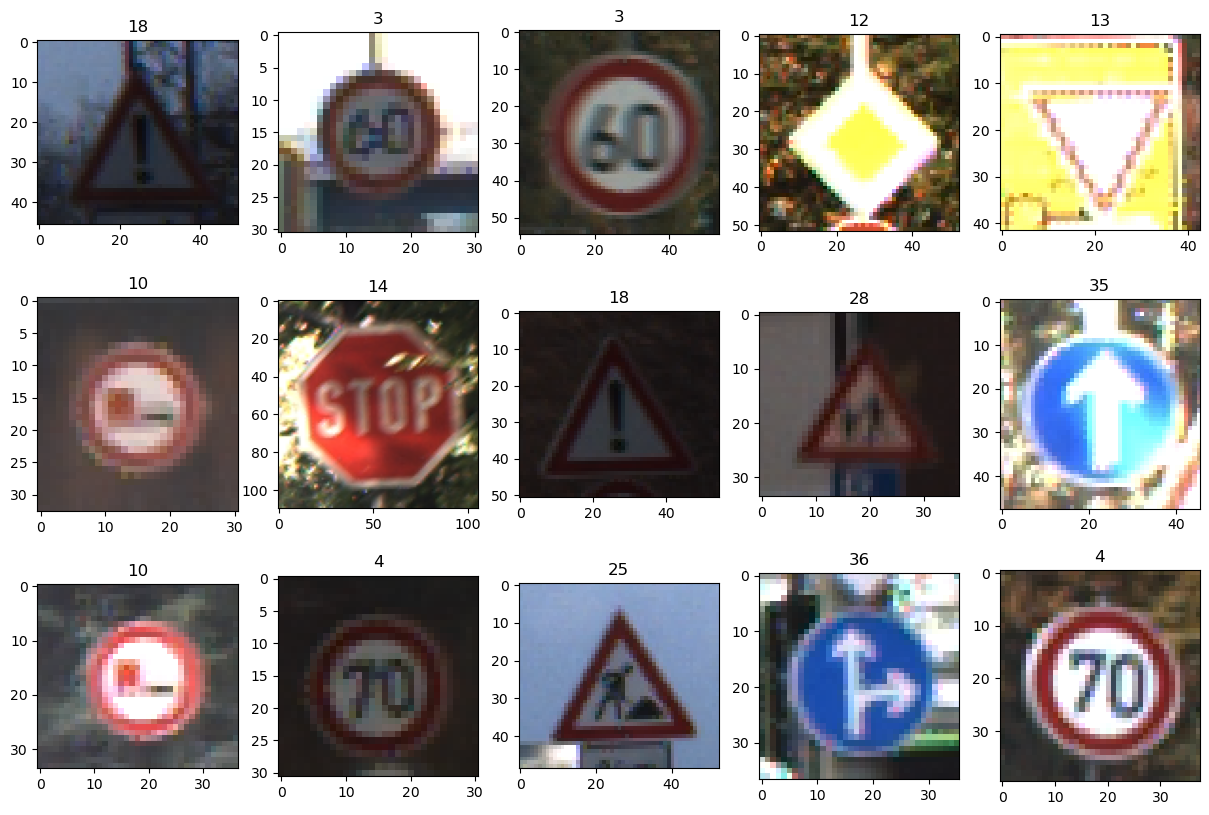

In [2]:
# Load the training labels
root = './data/' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
df = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = df.shape[0]

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, df.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(df.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [3]:
df["Path"] = root + df["Path"]
df

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,./data/Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,./data/Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,./data/Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,./data/Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,./data/Train/20/00020_00000_00004.png
...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,./data/Train/42/00042_00007_00025.png
39205,56,58,5,5,51,53,42,./data/Train/42/00042_00007_00026.png
39206,58,62,5,6,53,57,42,./data/Train/42/00042_00007_00027.png
39207,63,69,5,7,58,63,42,./data/Train/42/00042_00007_00028.png


In [4]:
# Extract class identifiers
# Hint: Check the csv
ids = df['ClassId'].unique()
ids, len(ids)

(array([20,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42]),
 43)

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

array([[<Axes: title={'center': 'ClassId'}>]], dtype=object)

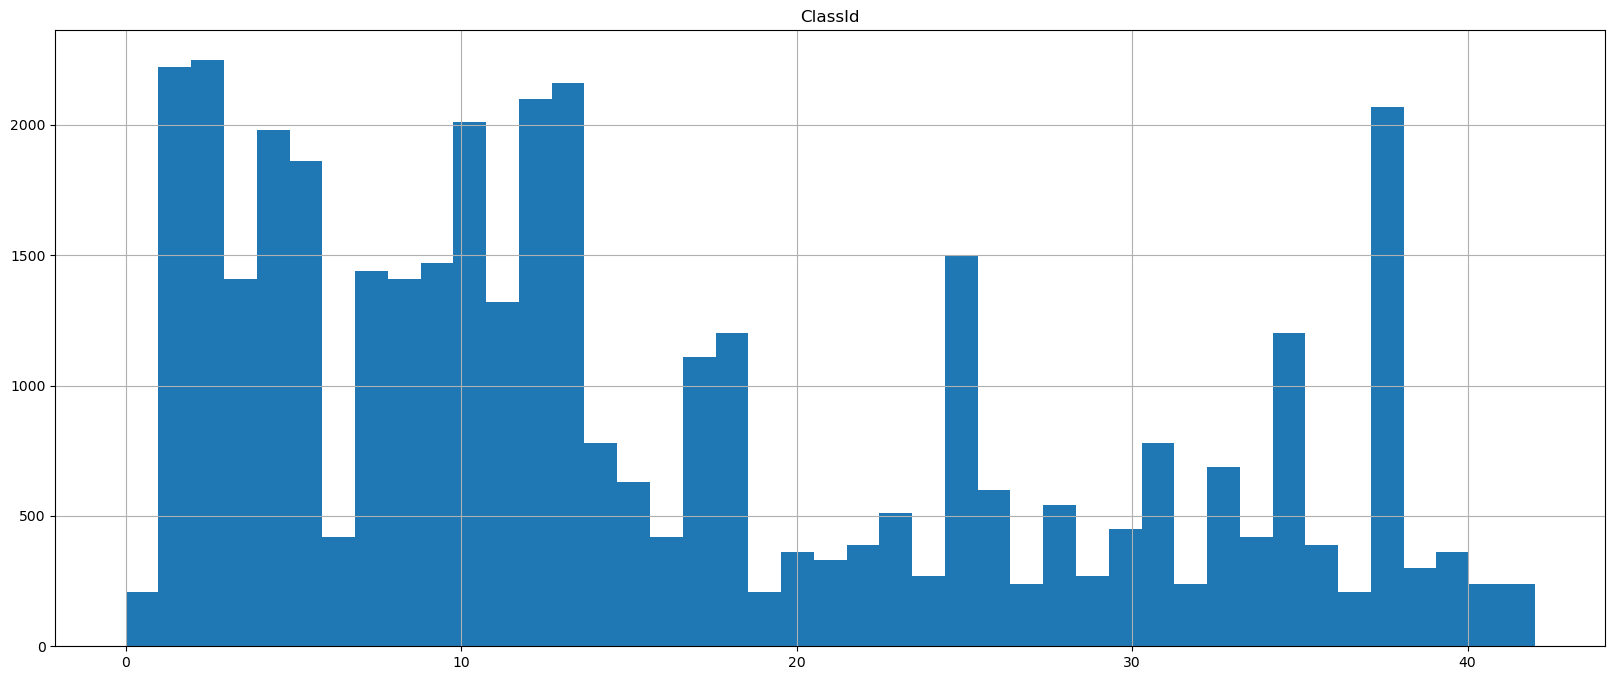

In [5]:
df.hist(column="ClassId", bins=len(ids), figsize=(20, 8))

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
* Are there any classes that are (significantly) over-represented or under-represeneted?

Dataset is unbalanced, here are the rows count for each class:

In [6]:
df["ClassId"].value_counts()

ClassId
2     2250
1     2220
13    2160
12    2100
38    2070
10    2010
4     1980
5     1860
25    1500
9     1470
7     1440
3     1410
8     1410
11    1320
18    1200
35    1200
17    1110
14     780
31     780
33     689
15     630
26     600
28     540
23     510
30     450
16     420
6      420
34     420
22     390
36     390
40     360
20     360
21     330
39     300
29     270
24     270
32     240
27     240
41     240
42     240
37     210
0      210
19     210
Name: count, dtype: int64

As we can see, some classes contain 10 times more data points that other

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?

Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

,Height,Width
count,39209.000000,39209.000000
mean,50.328930,50.835880
std,23.115423,24.306933
min,25.000000,25.000000
25%,35.000000,35.000000
50%,43.000000,43.000000
75%,58.000000,58.000000
max,225.000000,243.000000


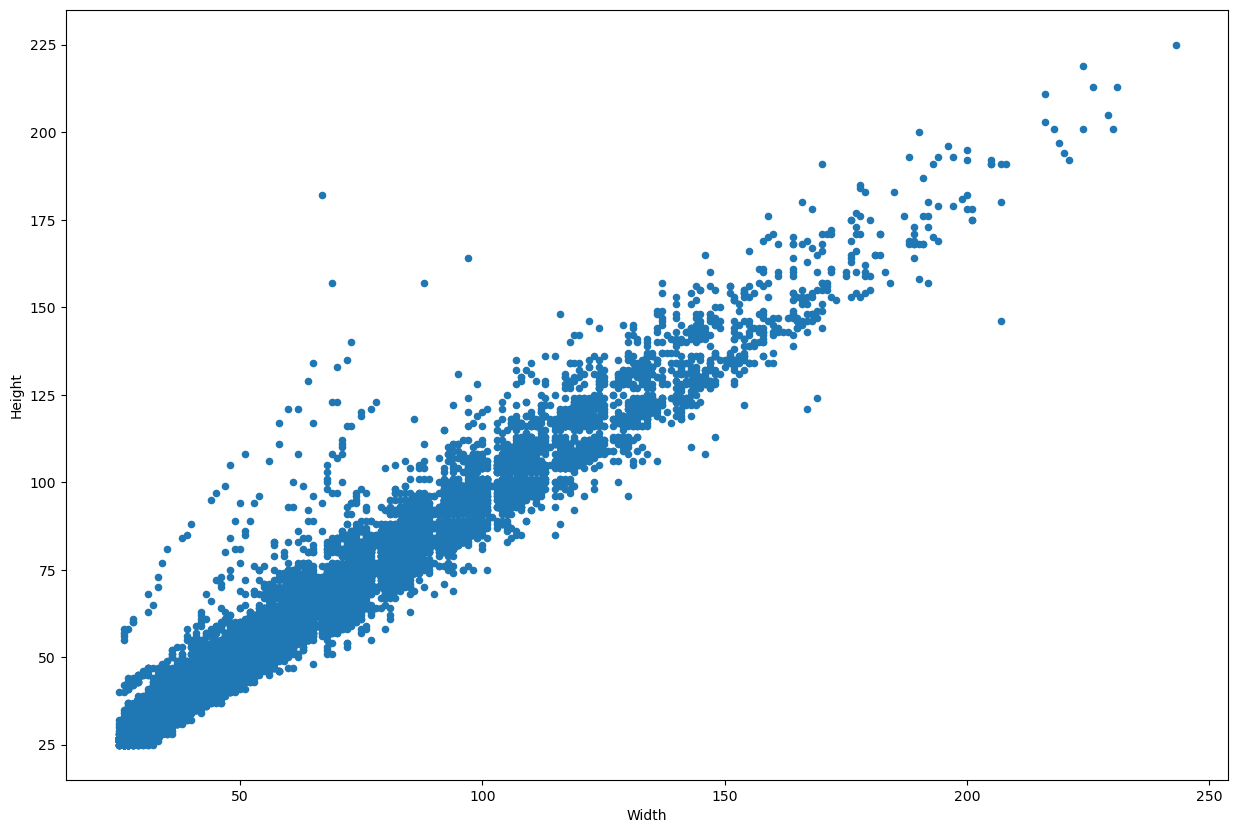

In [7]:
df.plot.scatter(x='Width', y='Height')
df[["Height", "Width"]].describe()

As we can see, spacial dimentions can be 10 times different as well

### Per channel brightness

In [8]:
def get_per_channel_brightness(image_path):
    img = Image.open(image_path).convert('RGB')
    arr = np.array(img)

    r_mean, g_mean, b_mean = arr.mean(axis=(0, 1))
    overall_brightness = arr.mean()

    return {"Red Brightness": r_mean, "Green Brightness": g_mean, "Blue Brightness": b_mean, "Overall brightness": overall_brightness}

In [9]:
brightness_data = df["Path"].apply(get_per_channel_brightness)
brightness_df = pd.DataFrame(brightness_data.tolist(), index=df.index)
df_final = df.join(brightness_df)

df_final

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,Red Brightness,Green Brightness,Blue Brightness,Overall brightness
0,27,26,5,5,22,20,20,./data/Train/20/00020_00000_00000.png,58.706553,58.388889,57.971510,58.355651
1,28,27,5,6,23,22,20,./data/Train/20/00020_00000_00001.png,59.165344,58.752646,59.043651,58.987213
2,29,26,6,5,24,21,20,./data/Train/20/00020_00000_00002.png,59.502653,58.340849,59.568966,59.137489
3,28,27,5,6,23,22,20,./data/Train/20/00020_00000_00003.png,58.560847,57.884921,58.604497,58.350088
4,28,26,5,5,23,21,20,./data/Train/20/00020_00000_00004.png,56.806319,56.293956,57.972527,57.024267
...,...,...,...,...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,./data/Train/42/00042_00007_00025.png,26.144231,27.385989,33.103709,28.877976
39205,56,58,5,5,51,53,42,./data/Train/42/00042_00007_00026.png,25.668719,27.212438,32.926108,28.602422
39206,58,62,5,6,53,57,42,./data/Train/42/00042_00007_00027.png,25.725250,27.035873,32.747775,28.502966
39207,63,69,5,7,58,63,42,./data/Train/42/00042_00007_00028.png,25.581781,26.994709,32.534161,28.370217


array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>], dtype=object)

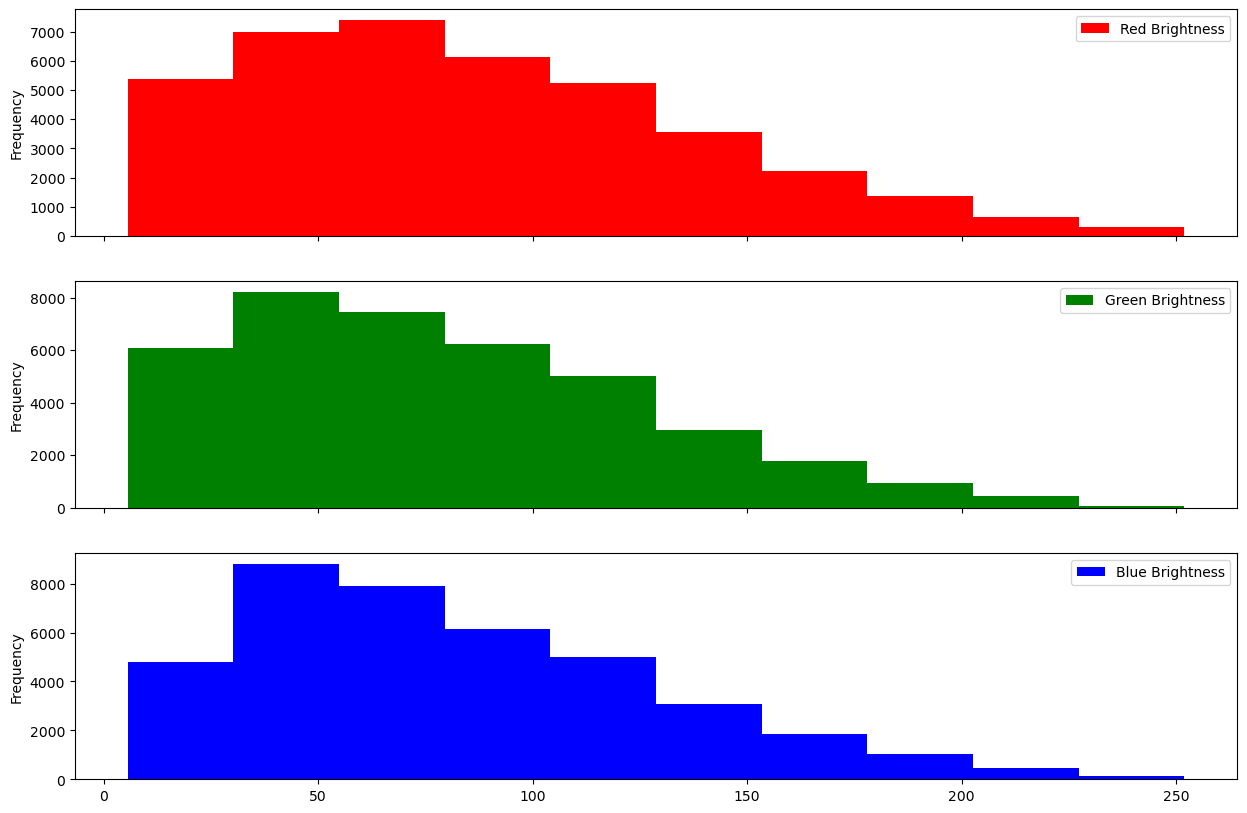

In [10]:
df_final.plot.hist(column=["Red Brightness", "Green Brightness", "Blue Brightness"], subplots=True, color=["red", "green", "blue"])

As we can see, the images are rather dark than bright

### Per class brightness

<Axes: xlabel='ClassId'>

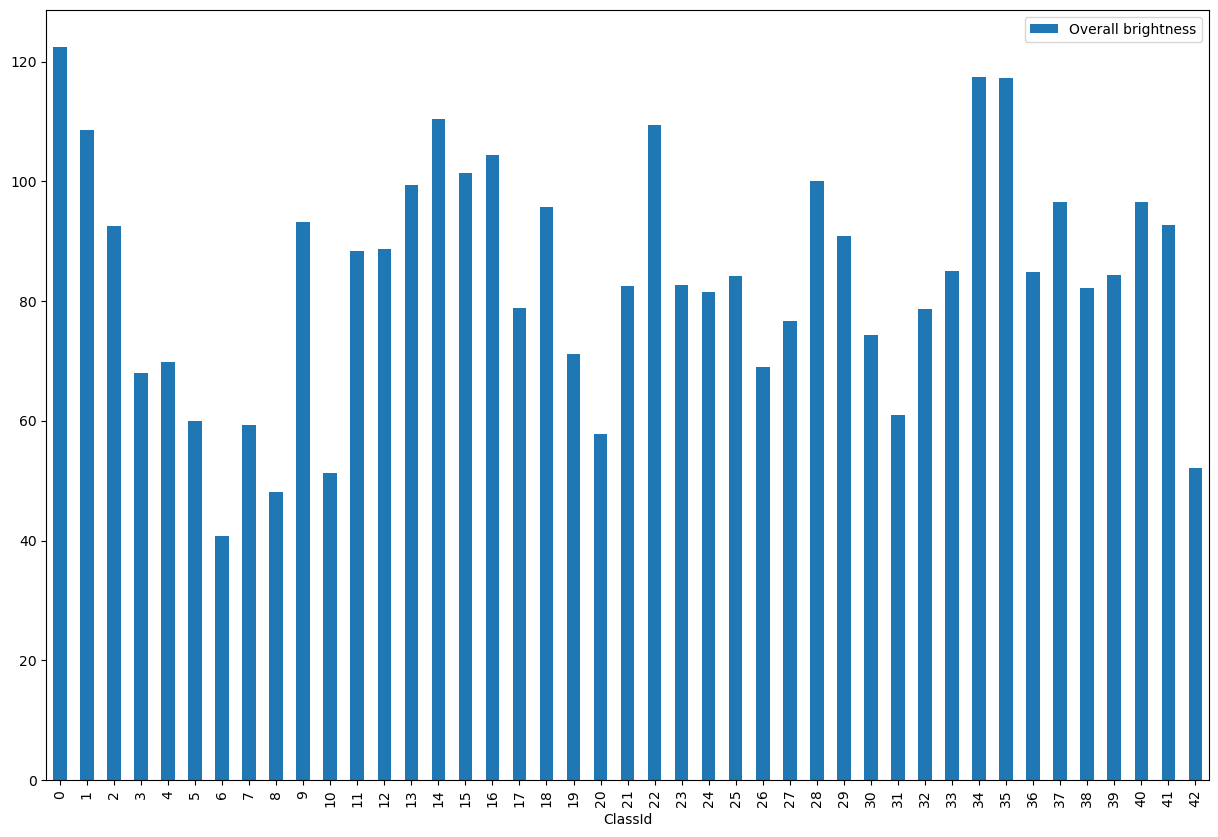

In [11]:
df_final.groupby("ClassId").agg({"Overall brightness": "mean"}).plot.bar()

As we can see, per class brightness highly depends on class